# LOINC Crosswalk — Test Set Evaluation

Confirms that the model selected on the validation set generalises to the held-out test set.  
No model selection happens here and configs are fixed from the ablation notebooks.

**Fixed config:** `lcn_method_dict_combined` · `tfidf_word (1,1)` · 0 distractors  

**Sections:**
1. Setup & data loading
2. TF-IDF test set evaluation
3. Headline: val vs test
4. Per-coverage-pattern breakdown
5. Noise robustness
6. Per-LOINC-code stability
7. Save results

## 1. Setup & Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import os
import sys

from src.model_building_utils import PipelineConfig, evaluate_pipeline
from src.ablation import load_data

# Get the repo root — works whether notebook is in root or notebooks/ folder
notebook_dir = Path(os.getcwd())
repo_root = notebook_dir if (notebook_dir / 'src').exists() else notebook_dir.parent

sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

sns.set_theme(style='whitegrid', font_scale=1.05)
pd.set_option('display.float_format', '{:.4f}'.format)
%matplotlib inline

DATA_DIR = Path('data/results')

BEST_CORPUS_STRATEGY = 'lcn_method_dict_combined'
BEST_MODEL_TYPE      = 'tfidf_word'
BEST_NGRAM           = (1, 1)

COVERAGE_ORDER = [
    'A+M+S+I','A+M+S','A+M+I','A+M',
    'A+S+I','A+S','A+I','A',
    'M+S+I','M+S','M+I','M',
    'S+I','S','I','NONE',
]
NOISE_ORDER = ['low', 'medium', 'high']

In [2]:
elr, loinc, _, rn_stopwords = load_data()

df_test = elr[elr['split'] == 'test'].copy()
df_val  = elr[elr['split'] == 'val'].copy()

print(f'Test: {len(df_test):,} rows, {df_test["loinc_num"].nunique()} codes')
print(f'Val:  {len(df_val):,} rows')

Test: 1,320 rows, 36 codes
Val:  5,280 rows


## 2. TF-IDF Test Set Evaluation

Three filter conditions on the fixed best config.

In [3]:
base_kwargs = dict(
    filter_strategy='none',
    corpus_strategy=BEST_CORPUS_STRATEGY,
    model_type=BEST_MODEL_TYPE,
    n_neighbors=6,
    extended_corpus=False,
    n_distractors=0,
)

test_results = []
for label, oracle, brand in [
    ('no_filter', False, False),
    ('oracle_filter', True, False),
    ('brand_filter', False, True),
]:
    print(f'Running {label}...')
    config = PipelineConfig(**base_kwargs, oracle_filter=oracle, brand_filter=brand)
    res = evaluate_pipeline(
        config=config, df_loinc=loinc, df_test=df_test,
        ngram_range=BEST_NGRAM, rn_stopwords=rn_stopwords,
    )
    res['filter_condition'] = label
    test_results.append(res)
    print(f'  mrr_grouped = {res["mrr_grouped"].mean():.4f}')

df_test_filter = pd.concat(test_results, ignore_index=True)

# Save immediately — expensive to recompute
df_test_filter.to_csv(DATA_DIR / 'test_filter_ablation.csv', index=False)
print('Saved: test_filter_ablation.csv')

Running no_filter...
  mrr_grouped = 0.7427
Running oracle_filter...
  mrr_grouped = 0.7664
Running brand_filter...
  mrr_grouped = 0.7427
Saved: test_filter_ablation.csv


## 3. Headline: Val vs Test


In [4]:
df_val_filter = pd.read_csv(DATA_DIR / 'filter_ablation.csv')

# Headline summary table
def headline_row(df, split):
    return (
        df.groupby('filter_condition')[['mrr_grouped','top1','top3','top5']]
        .mean().round(4)
        .assign(split=split, n=df.groupby('filter_condition').size())
    )

headline = pd.concat([headline_row(df_val_filter, 'val'),
                      headline_row(df_test_filter, 'test')])
headline['gap'] = (
    headline.groupby('filter_condition')['mrr_grouped']
    .transform(lambda x: x - x.iloc[0])
)
display(headline.reset_index())

,filter_condition,mrr_grouped,top1,top3,top5,split,n,gap
0,brand_filter,0.7476,0.2822,0.4356,0.5277,val,5280,0.0000
1,no_filter,0.7474,0.2820,0.4354,0.5277,val,5280,0.0000
2,oracle_filter,0.7666,0.2932,0.4712,0.5670,val,5280,0.0000
3,brand_filter,0.7427,0.2742,0.4280,0.5341,test,1320,-0.0049
4,no_filter,0.7427,0.2742,0.4273,0.5341,test,1320,-0.0047
5,oracle_filter,0.7664,0.2871,0.4644,0.5697,test,1320,-0.0002


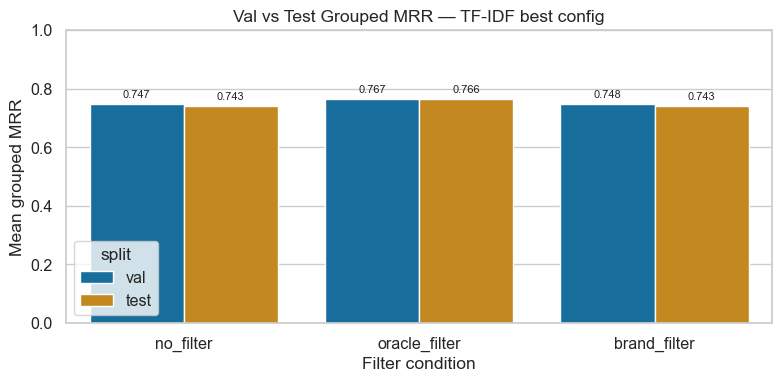

In [6]:
# Bar chart: val vs test by filter condition
plot_df = headline.reset_index()
plot_df['filter_condition'] = pd.Categorical(
    plot_df['filter_condition'],
    categories=['no_filter','oracle_filter','brand_filter'], ordered=True
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=plot_df, x='filter_condition', y='mrr_grouped',
            hue='split', palette='colorblind', ax=ax)
ax.set(xlabel='Filter condition', ylabel='Mean grouped MRR', ylim=(0, 1.0),
       title='Val vs Test Grouped MRR — TF-IDF best config')
ax.bar_label(ax.containers[0], fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(ax.containers[1], fmt='%.3f', fontsize=8, padding=3)
plt.tight_layout()
plt.savefig(DATA_DIR / 'test_val_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Coverage-Pattern Breakdown

No-filter condition only. 

In [33]:
df_test_nf = df_test_filter[df_test_filter['filter_condition'] == 'no_filter'].copy()
df_val_nf  = df_val_filter[df_val_filter['filter_condition'] == 'no_filter'].copy()

# Tag and concatenate
df_test_nf['split'] = 'test'
df_val_nf['split']  = 'val'
combined_nf = pd.concat([df_val_nf, df_test_nf], ignore_index=True)

# Summary table with counts and gap
cov_agg = (
    combined_nf.groupby(['coverage_pattern', 'split'])['mrr_grouped']
    .agg(['mean', 'count']).round(3)
    .unstack('split')
)
cov_agg.columns = ['_'.join(c) for c in cov_agg.columns]
cov_agg['gap'] = (cov_agg['mean_test'] - cov_agg['mean_val']).round(3)
present = [p for p in COVERAGE_ORDER if p in cov_agg.index]
display(cov_agg.reindex(present))

,mean_test,mean_val,count_test,count_val,gap
coverage_pattern,,,,,
A+M+S+I,0.6920,0.6840,46,150,0.0080
A+M+S,0.7040,0.7320,299,1178,-0.0280
A+M+I,0.8300,0.7920,90,326,0.0380
A+M,0.7900,0.7940,528,2184,-0.0040
A+S+I,0.4170,0.6410,6,52,-0.2240
A+S,0.6540,0.7290,58,271,-0.0750
A+I,0.6830,0.6120,30,107,0.0710
A,0.7290,0.7370,176,648,-0.0080
M+S+I,0.5620,0.6960,4,17,-0.1340


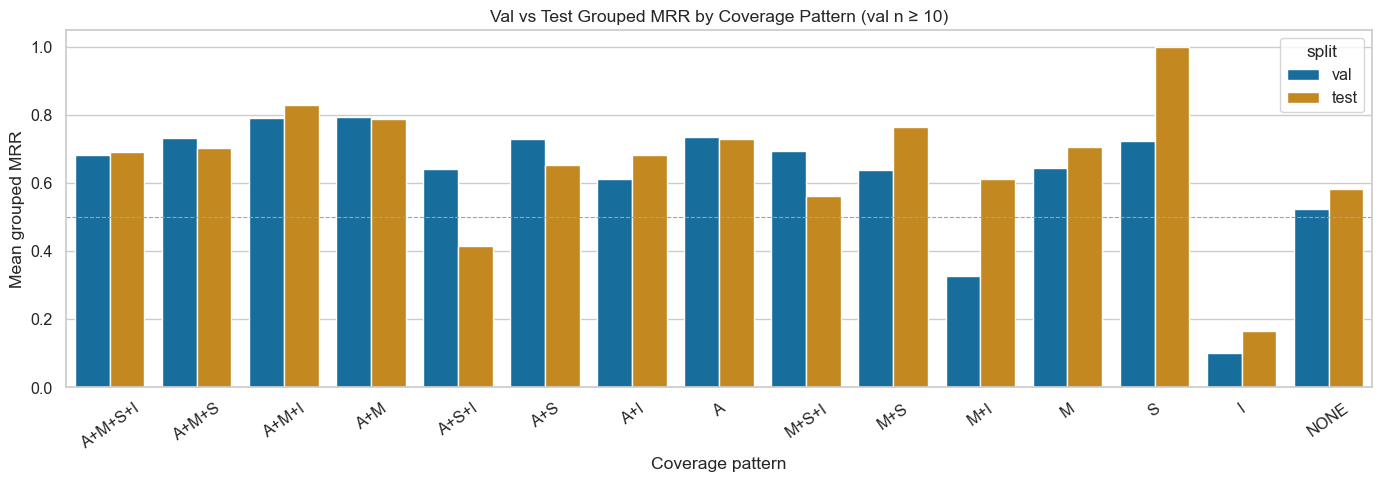

In [8]:
# Filter to patterns with enough val rows for a stable estimate
# Patterns with fewer than 10 val rows omitted from the chart.
keep_pats = cov_agg[cov_agg['count_val'] >= 10].index
plot_data = combined_nf[combined_nf['coverage_pattern'].isin(keep_pats)].copy()
plot_data['coverage_pattern'] = pd.Categorical(
    plot_data['coverage_pattern'], categories=[p for p in present if p in keep_pats], ordered=True
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(data=plot_data, x='coverage_pattern', y='mrr_grouped',
            hue='split', ax=ax, estimator='mean', errorbar=None, palette='colorblind')
ax.axhline(0.5, color='#94a3b8', linestyle='--', linewidth=0.8)
ax.set(xlabel='Coverage pattern', ylabel='Mean grouped MRR', ylim=(0, 1.05),
       title='Val vs Test Grouped MRR by Coverage Pattern (val n ≥ 10)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.savefig(DATA_DIR / 'test_coverage_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Noise Robustness

In [9]:
# Noise level summary table
noise_agg = (
    combined_nf.groupby(['noise_level', 'split'])['mrr_grouped']
    .agg(['mean', 'count']).round(3)
    .unstack('split')
)
noise_agg.columns = ['_'.join(c) for c in noise_agg.columns]
noise_agg['gap'] = (noise_agg['mean_test'] - noise_agg['mean_val']).round(3)
display(noise_agg.reindex(NOISE_ORDER))

,mean_test,mean_val,count_test,count_val,gap
noise_level,,,,,
low,0.7690,0.7620,998,3934,0.0070
medium,0.6670,0.7100,317,1305,-0.0430
high,0.3000,0.5100,5,41,-0.2100


23:29:00 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:29:00 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:29:00 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
23:29:00 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


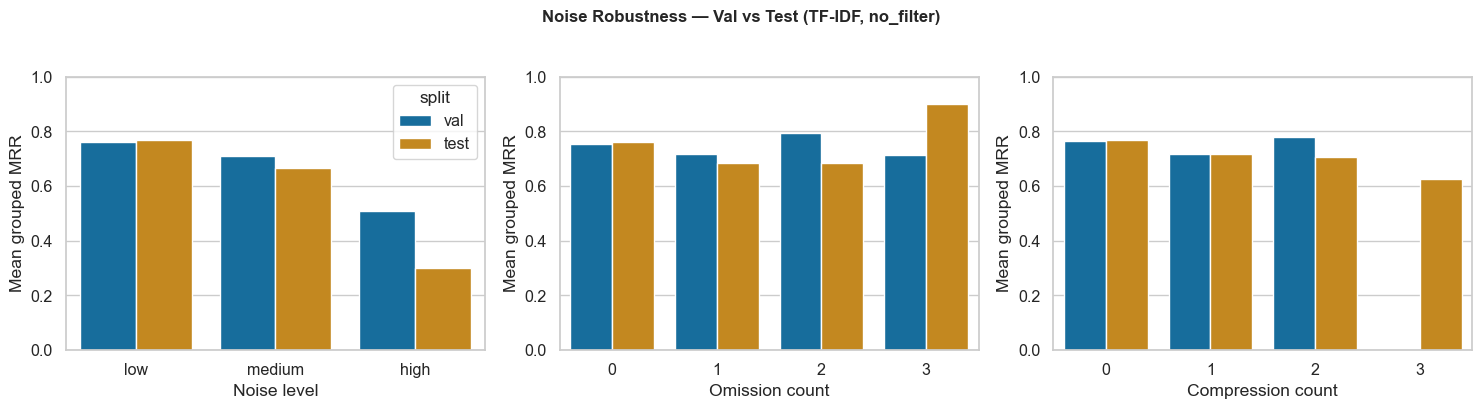

In [10]:
# 3-panel figure: noise_level / omission / compression
noise_dims = [
    ('noise_level',       'Noise level',       NOISE_ORDER),
    ('noise_omission',    'Omission count',    None),
    ('noise_compression', 'Compression count', None),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Noise Robustness — Val vs Test (TF-IDF, no_filter)',
             fontsize=12, fontweight='bold', y=1.02)

for ax, (col, xlabel, order) in zip(axes, noise_dims):
    plot_df = combined_nf.copy()
    if order:
        plot_df[col] = pd.Categorical(plot_df[col], categories=order, ordered=True)
    sns.barplot(data=plot_df, x=col, y='mrr_grouped', hue='split',
                ax=ax, estimator='mean', errorbar=None, palette='colorblind')
    ax.set(xlabel=xlabel, ylabel='Mean grouped MRR', ylim=(0, 1.0))
    if ax != axes[0]:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig(DATA_DIR / 'test_noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-LOINC-Code Stability


In [11]:
per_loinc = (
    combined_nf.groupby(['true_loinc', 'split'])['mrr_grouped']
    .agg(['mean', 'count']).round(3)
    .unstack('split')
)
per_loinc.columns = ['_'.join(c) for c in per_loinc.columns]
per_loinc['gap'] = (per_loinc['mean_test'] - per_loinc['mean_val']).round(3)
per_loinc = per_loinc.sort_values('mean_test')

print('Codes with test MRR = 0:')
display(per_loinc[per_loinc['mean_test'] == 0])
print('\nCodes with test MRR < 0.3:')
display(per_loinc[per_loinc['mean_test'] < 0.3])

Codes with test MRR = 0:


,mean_test,mean_val,count_test,count_val,gap
true_loinc,,,,,
94640-0,0.0000,0.0000,7,29,0.0000



Codes with test MRR < 0.3:


,mean_test,mean_val,count_test,count_val,gap
true_loinc,,,,,
94640-0,0.0000,0.0000,7,29,0.0000
96123-5,0.0200,0.0000,10,38,0.0200
94758-0,0.1420,0.2050,33,135,-0.0630
95423-0,0.1450,0.1560,14,58,-0.0110
94565-9,0.2830,0.1980,10,38,0.0850
95608-6,0.2990,0.2390,29,115,0.0600


In [34]:
loinc[loinc.loinc_num=="94640-0"]

,loinc_num,component,property,time_aspct,system,scale_typ,method_typ,class,status,long_common_name,relatednames2,paneltype,method_class,expanded_lcn
69,94640-0,SARS coronavirus 2 S gene,PrThr,Pt,Respiratory System Specimen,Ord,Probe.amp.tar,MICRO,ACTIVE,SARS-CoV-2 (COVID-19) S gene [Presence] in Res...,2019 Novel Coronavirus; 2019-nCoV; 3 Self-Sust...,NaN,naat,SARSCOV2 S GENE SGENE IN RESPIRATORY SYSTEM SP...


Pearson r: 0.968


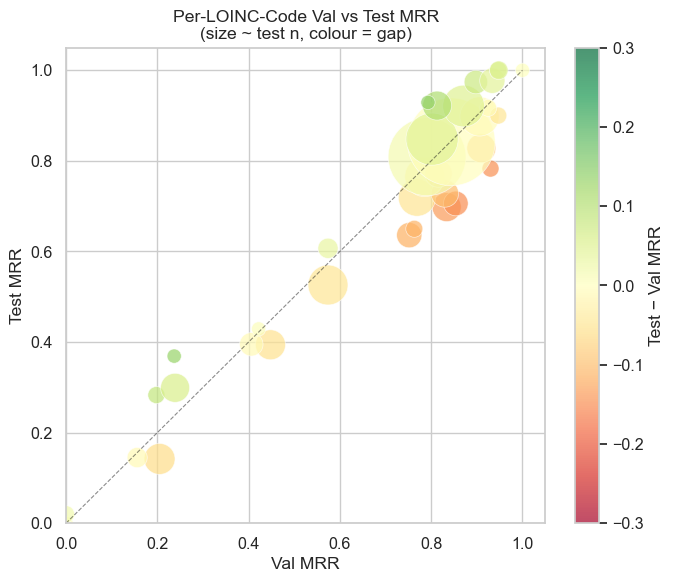

In [12]:
# Scatter: val MRR vs test MRR per LOINC code
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    per_loinc['mean_val'], per_loinc['mean_test'],
    s=per_loinc['count_test'] * 15,
    c=per_loinc['gap'], cmap='RdYlGn', vmin=-0.3, vmax=0.3,
    alpha=0.7, edgecolors='white', linewidth=0.5,
)
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Test − Val MRR')
ax.set(xlabel='Val MRR', ylabel='Test MRR', xlim=(0, 1.05), ylim=(0, 1.05),
       title='Per-LOINC-Code Val vs Test MRR\n(size ~ test n, colour = gap)')
print(f'Pearson r: {per_loinc[["mean_val","mean_test"]].corr().iloc[0,1]:.3f}')
plt.tight_layout()
plt.savefig(DATA_DIR / 'test_per_loinc_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
display(per_loinc.rename(columns={
    'mean_val':'val_mrr','count_val':'val_n',
    'mean_test':'test_mrr','count_test':'test_n'
}))

,test_mrr,val_mrr,test_n,val_n,gap
true_loinc,,,,,
94640-0,0.0000,0.0000,7,29,0.0000
96123-5,0.0200,0.0000,10,38,0.0200
94758-0,0.1420,0.2050,33,135,-0.0630
95423-0,0.1450,0.1560,14,58,-0.0110
94565-9,0.2830,0.1980,10,38,0.0850
95608-6,0.2990,0.2390,29,115,0.0600
82166-0,0.3690,0.2370,7,29,0.1320
95209-3,0.3940,0.4480,31,125,-0.0540
94502-2,0.3950,0.4060,19,77,-0.0110


## 7. Save Results

In [14]:
per_loinc.to_csv(DATA_DIR / 'test_per_loinc_results.csv')

(
    df_test_filter.groupby('filter_condition')
    .agg(mrr_grouped=('mrr_grouped','mean'), top1=('top1','mean'),
         top3=('top3','mean'), top5=('top5','mean'), n=('mrr_grouped','count'))
    .round(4).reset_index()
    .to_csv(DATA_DIR / 'test_headline_summary.csv', index=False)
)

(
    df_test_filter.groupby(['filter_condition','coverage_pattern'])['mrr_grouped']
    .mean().unstack('filter_condition').round(4)
    .to_csv(DATA_DIR / 'test_filter_summary_by_coverage.csv')
)

(
    combined_nf.groupby(['noise_level','split'])['mrr_grouped'].mean()
    .unstack('split').reindex(NOISE_ORDER).round(4)
    .to_csv(DATA_DIR / 'test_noise_summary.csv')
)

for f in ['test_filter_ablation.csv','test_per_loinc_results.csv',
          'test_headline_summary.csv','test_filter_summary_by_coverage.csv',
          'test_noise_summary.csv']:
    print(f'  data/results/{f}')

  data/results/test_filter_ablation.csv
  data/results/test_per_loinc_results.csv
  data/results/test_headline_summary.csv
  data/results/test_filter_summary_by_coverage.csv
  data/results/test_noise_summary.csv


## Summary

In [35]:
nf = lambda df: df[df['filter_condition']=='no_filter']['mrr_grouped'].mean()
print('TEST SET — lcn_method_dict_combined, word (1,1)')
print(f'No filter:     {nf(df_test_filter):.4f}  (val: {nf(df_val_filter):.4f},  gap: {nf(df_test_filter)-nf(df_val_filter):+.4f})')
for cond in ['oracle_filter','brand_filter']:
    mrr = df_test_filter[df_test_filter['filter_condition']==cond]['mrr_grouped'].mean()
    print(f'{cond:15s}: {mrr:.4f}')
nf_df = df_test_filter[df_test_filter['filter_condition']=='no_filter']
print(f'Top-1: {nf_df["top1"].mean():.4f}  Top-3: {nf_df["top3"].mean():.4f}  Top-5: {nf_df["top5"].mean():.4f}')

TEST SET — lcn_method_dict_combined, word (1,1)
No filter:     0.7427  (val: 0.7474,  gap: -0.0048)
oracle_filter  : 0.7664
brand_filter   : 0.7427
Top-1: 0.2742  Top-3: 0.4273  Top-5: 0.5341
